In [28]:
import pandas as pd
import numpy as np
import json
from vnstock import register_user, Company
from pypfopt import expected_returns, risk_models, CovarianceShrinkage, plotting
from pypfopt.efficient_frontier import EfficientFrontier
import matplotlib.pyplot as plt

In [18]:
# Register vnstock
register_user('vnstock_2d2225369316c09dd7eb5cb6e00a6a67')

✓ API key đã được lưu thành công! (API key saved successfully!)
Bạn đang sử dụng Phiên bản cộng đồng (60 requests/phút)
(You are using Community version - 60 requests/minute)

Để tham gia gói thành viên tài trợ (To join sponsor membership):
  Truy cập: https://vnstocks.com/insiders-program
✓ API key đã được lưu thành công! (✓ API key saved successfully! vnst***6a67
✓ Bạn đang sử dụng gói Cộng đồng (✓ You are using Community Edition - 60 requests/min)


True

In [19]:
prices_pivot = pd.read_csv('../data/processed/vn30_prices_processed.csv', index_col=0, parse_dates=True)
log_returns = pd.read_csv('../data/processed/vn30_log_returns_processed.csv', index_col=0, parse_dates=True)

with open('../data/processed/vn30_membership_point_in_time.json') as f:
    pit_membership = json.load(f)

### **Strategy 1 - Equal-weight**

- **Idea:** each ticker in the basket has an equal weight (1/30 if there are 30 tickers)
- This is "naive" benchmark, used to compare whether other complicated strategies are worthwhile

In [30]:
# Equal-weight
latest_period = max(pit_membership.keys())
symbols_at_period = pit_membership[latest_period]

n = len(symbols_at_period)
equal_weights = pd.Series(1 / n, index=symbols_at_period)
print(equal_weights)

LPB    0.033333
FPT    0.033333
TPB    0.033333
MBB    0.033333
VIC    0.033333
VPB    0.033333
ACB    0.033333
BSR    0.033333
VHM    0.033333
BID    0.033333
GAS    0.033333
STB    0.033333
VCB    0.033333
HPG    0.033333
MWG    0.033333
SHB    0.033333
VJC    0.033333
VPL    0.033333
VIB    0.033333
SAB    0.033333
SSB    0.033333
SSI    0.033333
HDB    0.033333
CTG    0.033333
PLX    0.033333
GVR    0.033333
MSN    0.033333
TCB    0.033333
VNM    0.033333
VRE    0.033333
dtype: float64


### **Strategy 2 - Market-cap-weigt**

In [13]:
# Test data collection for a specific company
company = Company(symbol='VNM', source='KBS')
overview = company.overview()
print(overview)

                                      business_model symbol founded_date  \
0  \n- Chế biến, sản xuất kinh doanh sữa và các s...    VNM   01/10/2003   

   charter_capital  number_of_employees listing_date  par_value exchange  \
0            20900                 9906   19/01/2006      10000     HOSE   

   listing_price  listed_volume  ...              phone  \
0          53000           2090  ...  (84.28) 5415 5555   

                             fax                     email  \
0  (84.28) 5416 1226 - 5416 1230  vinamilk@vinamilk.com.vn   

                       website  \
0  https://www.vinamilk.com.vn   

                                            branches  \
0  - Tại Hà Nội: 57 Trần Duy Hưng - P. Trung Hòa ...   

                                             history free_float_percentage  \
0  \n- Năm 1976: Tiền thân của công ty là Công ty...        20899554450000   

  free_float outstanding_shares           as_of_date  
0      10000         2089955445  2025-12-31T00:00:00  



In [15]:
market_caps = {} # dict: symbol -> current market cap
for sym in symbols_at_period:
    try:
        company = Company(symbol=sym, source='KBS')
        overview = company.overview()
        outstanding_shares = int(overview['outstanding_shares'].values[0])

        # Closing price (unit: thousands of VND) at the latest date in the prices_pivot DataFrame
        latest_price_thousand_vnd = prices_pivot[sym].dropna().iloc[-1]
        latest_price_vnd = latest_price_thousand_vnd * 1000

        market_caps[sym] = latest_price_vnd * outstanding_shares
    except Exception as e:
        print(f"Error fetching data for {sym}: {e}")

market_caps = pd.Series(market_caps)
market_cap_weights = market_caps / market_caps.sum()
print(market_cap_weights.sort_values(ascending=False))

VIC    0.259288
VHM    0.094325
VCB    0.081296
BID    0.048401
CTG    0.041263
TCB    0.037537
VPB    0.033940
MBB    0.032032
HPG    0.030576
GAS    0.029066
LPB    0.024497
VPL    0.024427
STB    0.021312
HDB    0.020562
GVR    0.020478
ACB    0.020304
BSR    0.019681
FPT    0.019179
MWG    0.018142
VNM    0.017817
MSN    0.017186
VJC    0.016545
SSI    0.010506
SHB    0.010142
VRE    0.009931
SAB    0.009577
SSB    0.008737
VIB    0.008727
PLX    0.007349
TPB    0.007176
dtype: float64


### **Strategy 3 - Mean-variance Optimization (Markowitz)**

Using `PyPortfolioOpt`

In [20]:
# Collect correct price panel for the current period
prices_subset = prices_pivot[symbols_at_period].dropna(how='any')

# Estimate expected return and covariance
mu = expected_returns.mean_historical_return(prices_subset)
S = risk_models.sample_cov(prices_subset)

# Optimize followed Max Sharpe
ef = EfficientFrontier(mu, S)
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()
print(cleaned_weights)

ef.portfolio_performance(verbose=True) # print expected return, volatility, and Sharpe ratio

OrderedDict({'LPB': 0.12984, 'FPT': 0.0, 'TPB': 0.0, 'MBB': 0.0, 'VIC': 0.57037, 'VPB': 0.0, 'ACB': 0.0, 'BSR': 0.17283, 'VHM': 0.0, 'BID': 0.0, 'GAS': 0.0, 'STB': 0.10719, 'VCB': 0.0, 'HPG': 0.0, 'MWG': 0.0, 'SHB': 0.0, 'VJC': 0.01977, 'VPL': 0.0, 'VIB': 0.0, 'SAB': 0.0, 'SSB': 0.0, 'SSI': 0.0, 'HDB': 0.0, 'CTG': 0.0, 'PLX': 0.0, 'GVR': 0.0, 'MSN': 0.0, 'TCB': 0.0, 'VNM': 0.0, 'VRE': 0.0})
Expected annual return: 235.8%
Annual volatility: 32.9%
Sharpe Ratio: 7.16


(np.float64(2.3580288934764018),
 np.float64(0.3293820491155372),
 np.float64(7.1589477927173775))

*Note:* With small dataset, covariance matrix can be noisy. If the observed optimized weights are too extreme, consider replace by shrinkage estimator:

In [25]:
S_shrunk = CovarianceShrinkage(prices_subset).ledoit_wolf()
ef = EfficientFrontier(mu, S_shrunk)
weights = ef.max_sharpe()
cleaned_weights = ef.clean_weights()
print(cleaned_weights)
ef.portfolio_performance(verbose=True)

OrderedDict({'LPB': 0.12715, 'FPT': 0.0, 'TPB': 0.0, 'MBB': 0.0, 'VIC': 0.56798, 'VPB': 0.0, 'ACB': 0.0, 'BSR': 0.17246, 'VHM': 0.0, 'BID': 0.0, 'GAS': 0.0, 'STB': 0.10732, 'VCB': 0.0, 'HPG': 0.0, 'MWG': 0.0, 'SHB': 0.0, 'VJC': 0.02509, 'VPL': 0.0, 'VIB': 0.0, 'SAB': 0.0, 'SSB': 0.0, 'SSI': 0.0, 'HDB': 0.0, 'CTG': 0.0, 'PLX': 0.0, 'GVR': 0.0, 'MSN': 0.0, 'TCB': 0.0, 'VNM': 0.0, 'VRE': 0.0})
Expected annual return: 235.2%
Annual volatility: 32.3%
Sharpe Ratio: 7.28


(np.float64(2.3521863239030143),
 np.float64(0.3232440851822797),
 np.float64(7.27681164707654))

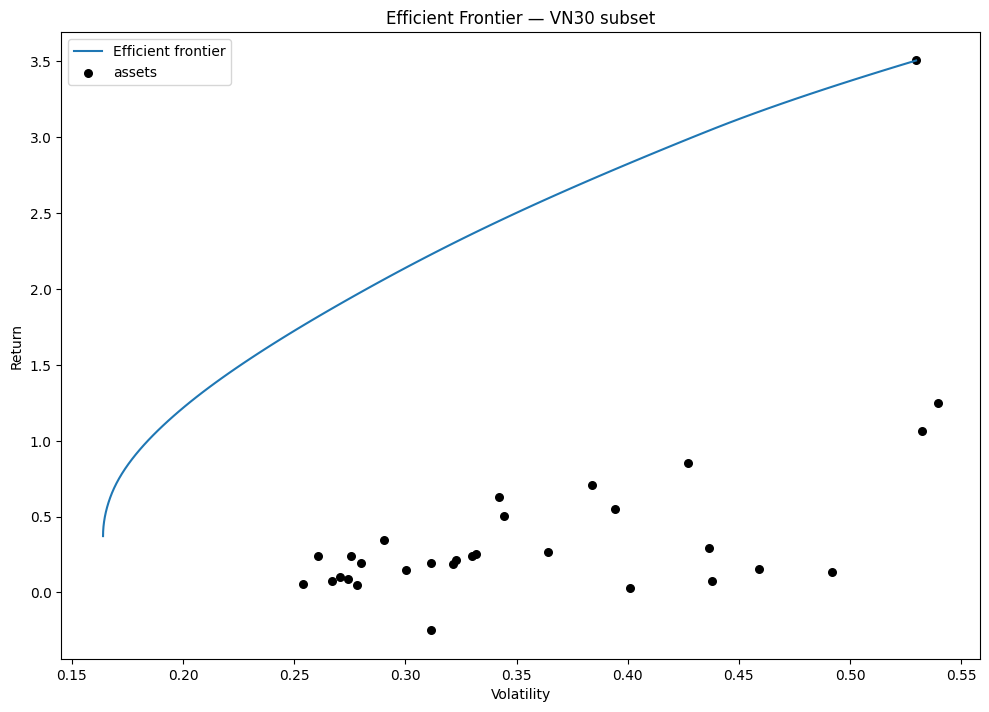

In [27]:
# Draw Efficient Frontier
fig, ax = plt.subplots(figsize=(10, 7))
ef_plot = EfficientFrontier(mu, S)
plotting.plot_efficient_frontier(ef_plot, ax=ax, show_assets=True)

# Mark the equal-weight and market-cap-weight points on the same chart for visual comparison
ax.set_title('Efficient Frontier — VN30 subset')
plt.show()

In [31]:
# Compare 3 strategies
comparison = pd.DataFrame({
    'Equal-weight': equal_weights,
    'Market-cap-weight': market_cap_weights,
    'Max-Sharpe (Markowitz)': pd.Series(cleaned_weights)
}).fillna(0)

print(comparison.round(4))

# Compared performance metrics
for name, weights in [('Equal-weight', equal_weights),
                      ('Market-cap-weight', market_cap_weights),
                      ('Markowitz', pd.Series(cleaned_weights))]:
    port_return = (weights * mu).sum()
    port_vol = np.sqrt(weights.values @ S.values @ weights.values)
    sharpe = port_return / port_vol
    print(f"{name}: return={port_return:.2f}, vol={port_vol:.2f}, sharpe={sharpe:.2f}")

     Equal-weight  Market-cap-weight  Max-Sharpe (Markowitz)
LPB        0.0333             0.0245                  0.1272
FPT        0.0333             0.0192                  0.0000
TPB        0.0333             0.0072                  0.0000
MBB        0.0333             0.0320                  0.0000
VIC        0.0333             0.2593                  0.5680
VPB        0.0333             0.0339                  0.0000
ACB        0.0333             0.0203                  0.0000
BSR        0.0333             0.0197                  0.1725
VHM        0.0333             0.0943                  0.0000
BID        0.0333             0.0484                  0.0000
GAS        0.0333             0.0291                  0.0000
STB        0.0333             0.0213                  0.1073
VCB        0.0333             0.0813                  0.0000
HPG        0.0333             0.0306                  0.0000
MWG        0.0333             0.0181                  0.0000
SHB        0.0333       

### **Analysis & Next Steps**

- **Observation:** The Max-Sharpe (Markowitz) solution reports a higher Sharpe ratio but produces highly concentrated weights.
- **Interpretation:** Concentration suggests the optimizer may be overfitting to a noisy covariance estimate.
- **Mitigation:** Use covariance shrinkage, longer return windows, or robust/stable optimization to reduce overfitting.
- **Action plan:** Schedule robustness checks (shrinkage, rolling-window validation, stress tests) in Week 3 or Week 5.